# **AI/ML Explore 4 - Color-Based Clustering with K-Means**

### **Crop Players Image For Training**

In [ ]:
!pip install -q gdown supervision ultralytics torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.3 MB/s eta 0:00:00


In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1088_ljxihPlpIkuqQt4olBXxhh3wOBb5/view?usp=sharing" -O "ManCity_ManUnited.mp4"
!gdown --fuzzy "https://drive.google.com/file/d/1V-vIyYlModxdoXsvv7OHhJGnA9NEnNrB/view?usp=sharing" -O "Football_A.mp4"
!gdown --fuzzy "https://drive.google.com/file/d/1Fp8dyYBeUEO89p1aXPgRJ_sTWFFfs7ct/view?usp=sharing" -O "Football_B.mp4"

!gdown --fuzzy "https://drive.google.com/file/d/1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p/view?usp=sharing" -O "object_detection_model.pt"

Downloading...
From: https://drive.google.com/uc?id=1088_ljxihPlpIkuqQt4olBXxhh3wOBb5
To: /content/ManCity_ManUnited.mp4
100% 84.4M/84.4M [00:00<00:00, 110MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V-vIyYlModxdoXsvv7OHhJGnA9NEnNrB
To: /content/Football_A.mp4
100% 20.9M/20.9M [00:00<00:00, 68.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Fp8dyYBeUEO89p1aXPgRJ_sTWFFfs7ct
To: /content/Football_B.mp4
100% 22.0M/22.0M [00:00<00:00, 65.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p
From (redirected): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p&confirm=t&uuid=9ffc0ef1-6dae-4257-9c12-1343cd359700
To: /content/object_detection_model.pt
100% 118M/118M [00:01<00:00, 116MB/s]


In [ ]:
from tqdm import tqdm
import supervision as sv
from ultralytics import YOLO

SOURCE_VIDEO_PATH = "/content/Football_B.mp4"
MODEL = YOLO("/content/object_detection_model.pt")
STRIDE = 30 # instead of process each frame at one time, process 1 frame every 30 frame
PLAYER_ID = 2 # id for player (0 = ball, 1 = goalkeeper, 2 = player, 3 = referee)

def extract_crops(source_video_path: str):
  crops = []
  frame_generator = sv.get_video_frames_generator(source_video_path, stride=STRIDE) # creates a lazy iterator that yields one frame at a time


  for frame in tqdm(frame_generator, desc="Extracting crops"):
    result = MODEL(frame, conf=0.3)[0] # runs YOLO on the current frame, only keeping detections with 30%+ confidence
    detections = sv.Detections.from_ultralytics(result) # turn YOLO output to SV Detection Object
    detections = detections.with_nms(threshold=0.5, class_agnostic=True) # remove duplicate box from YOLO output
    detections = detections[detections.class_id == PLAYER_ID] # take only the player detection
    # Extract crops
    crops += [
        sv.crop_image(frame, xyxy) # cut out the exact rectangle from the frame according to xyxy coordinate (top left coor and bottom right coor)
        for xyxy
        in detections.xyxy # give the coordinate of the box
    ]

  return crops # numpy array format

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
crops = extract_crops(SOURCE_VIDEO_PATH)

Extracting crops: 0it [00:00, ?it/s]


0: 736x1280 21 players, 2 referees, 128.0ms
Speed: 18.4ms preprocess, 128.0ms inference, 36.9ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 1it [00:02,  2.96s/it]


0: 736x1280 1 ball, 21 players, 2 referees, 32.2ms
Speed: 13.9ms preprocess, 32.2ms inference, 0.7ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 2it [00:03,  1.29s/it]

...

Extracting crops: 23it [00:05,  9.08it/s]


0: 736x1280 22 players, 2 referees, 32.2ms
Speed: 9.5ms preprocess, 32.2ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 24it [00:05,  9.07it/s]


0: 736x1280 21 players, 2 referees, 32.1ms
Speed: 11.8ms preprocess, 32.1ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 25it [00:05,  4.45it/s]


In [ ]:
len(crops)

508

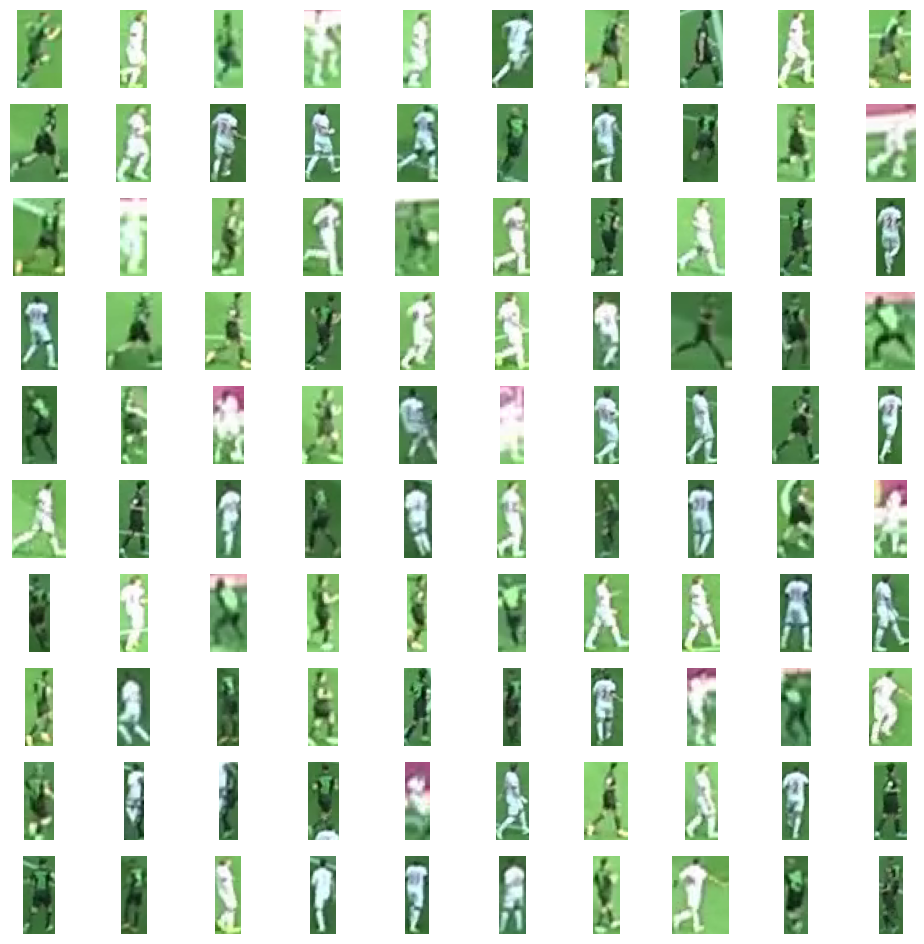

In [ ]:
# Display the first 100 players crop image in a 10x10 grid
sv.plot_images_grid(crops[200:300], grid_size=(10, 10))

### **SigLIP (Sigmoid Loss for Language-Text Pre-Trained**

In [ ]:
# Transformers - Hugging Face Library that host thousand of pre-trained models
# SiglipVision Model - the "Image Encoder" part of SigLIP
# AutoProcessor - handle preprocessing images before feed it to the SigLIP model
# Torch - deep learning framework
from transformers import AutoProcessor, SiglipVisionModel
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMBEDDING_MODEL = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224").to(DEVICE)
EMBEDDING_PROCESSOR = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.head.bias                                         | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj

...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from more_itertools import chunked
import numpy as np

# We process 32 crops each time
BATCH_SIZE = 32

# Convert OpenCV numpy array format to Pillow (PIL) format because SigLIP required
crops = [sv.cv2_to_pillow(crop) for crop in crops]

# A lazy iterator like frame_generator that create the next batch of 32 crops each run
batches = chunked(crops, BATCH_SIZE)
data = [] # array to hold all the embedding

# Letting the model know that we not training so do not track gradients
# Only inference
with torch.no_grad():
  for batch in tqdm(batches, desc='Extracting embedding'):
    inputs = EMBEDDING_PROCESSOR(images=batch, return_tensors="pt").to(DEVICE) # return PyTorch tensors & move data to GPU
    outputs = EMBEDDING_MODEL(**inputs) # run SigLIP model on proccessed inputs -> (32, 196, 768)
    embeddings = outputs.pooler_output.cpu().numpy() # (32, 196, 768) -> (32, 768)
    data.append(embeddings) # append (32, 768) to the data array

# Stacks all batches into one final array
data = np.concatenate(data)

Extracting embedding: 16it [00:02,  5.73it/s]


In [ ]:
data.shape

(508, 768)

### **UMAP (Uniform Manifold Approximation and Projection) and K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
import umap

REDUCER = umap.UMAP(n_components=3) # reduce 768 dimensions down to 3 dimensions
CLUSTERING_MODEL = KMeans(n_clusters=2) # cluster into 2 teams

In [ ]:
# Learn reduction and apply reduction
# From 768 numbers to 3 numbers
projections = REDUCER.fit_transform(data)

In [ ]:
projections.shape

(508, 3)

In [ ]:
# Learn the clusters and assign labels to same data
clusters = CLUSTERING_MODEL.fit_predict(projections)

In [ ]:
clusters[:10]

array([1, 1, 0, 0, 0, 1, 1, 1, 1, 0], dtype=int32)

In [ ]:
team_0 = [
    crop
    for crop, cluster
    in zip(crops, clusters)
    if cluster == 0
]

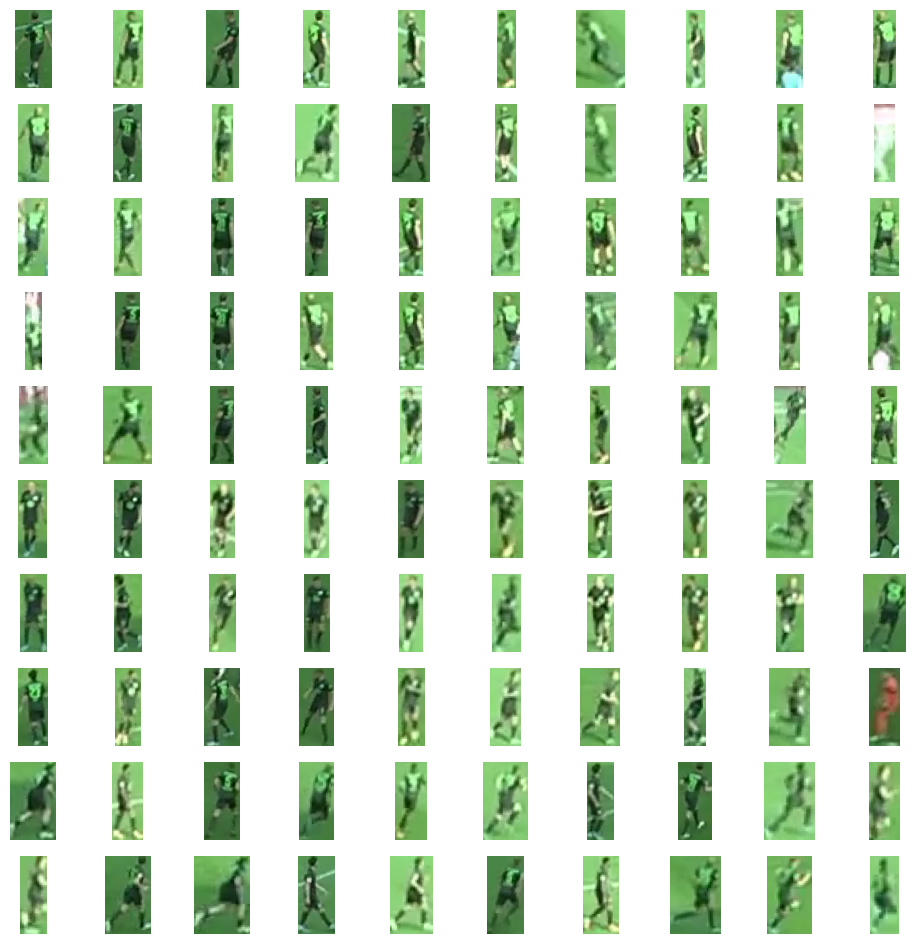

In [ ]:
sv.plot_images_grid(team_0[:100], grid_size=(10, 10))

### **Visualization**


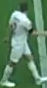
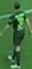
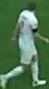
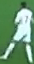
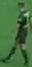
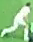
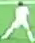
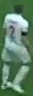
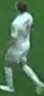
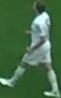
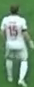
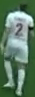
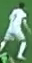
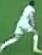
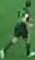
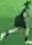
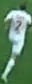
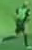
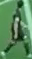
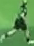
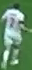
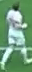
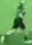
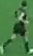
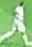
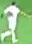
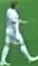
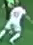
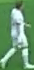
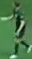
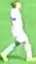
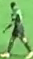
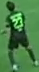
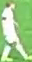
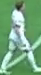
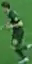
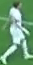

In [ ]:
import plotly.graph_objects as go
import numpy as np
from typing import Dict, List
from IPython.core.display import display, HTML
from PIL import Image
import base64
from io import BytesIO


def pil_image_to_data_uri(image: Image.Image) -> str:
    buffered = BytesIO()
    image.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{img_str}"


def display_projections(
    labels: np.ndarray,
    projections: np.ndarray,
    images: List[Image.Image],
    show_legend: bool = False,
    show_markers_with_text: bool = True
) -> None:
    image_data_uris = {f"image_{i}": pil_image_to_data_uri(image) for i, image in enumerate(images)}
    image_ids = np.array([f"image_{i}" for i in range(len(images))])

    unique_labels = np.unique(labels)
    traces = []
    for unique_label in unique_labels:
        mask = labels == unique_label
        customdata_masked = image_ids[mask]
        trace = go.Scatter3d(
            x=projections[mask][:, 0],
            y=projections[mask][:, 1],
            z=projections[mask][:, 2],
            mode='markers+text' if show_markers_with_text else 'markers',
            text=labels[mask],
            customdata=customdata_masked,
            name=str(unique_label),
            marker=dict(size=8),
            hovertemplate="<b>class: %{text}</b><br>image ID: %{customdata}<extra></extra>"
        )
        traces.append(trace)

    # Calculate shared range for cube appearance
    all_axes = projections
    min_val = np.min(all_axes)
    max_val = np.max(all_axes)
    padding = (max_val - min_val) * 0.05
    axis_range = [min_val - padding, max_val + padding]

    fig = go.Figure(data=traces)
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X', range=axis_range),
            yaxis=dict(title='Y', range=axis_range),
            zaxis=dict(title='Z', range=axis_range),
            aspectmode='cube'  # Ensures equal scaling
        ),
        width=1000,
        height=1000,
        showlegend=show_legend
    )

    plotly_div = fig.to_html(full_html=False, include_plotlyjs=False, div_id="scatter-plot-3d")

    javascript_code = f"""
    <script>
        function displayImage(imageId) {{
            var imageElement = document.getElementById('image-display');
            var placeholderText = document.getElementById('placeholder-text');
            var imageDataURIs = {image_data_uris};
            imageElement.src = imageDataURIs[imageId];
            imageElement.style.display = 'block';
            placeholderText.style.display = 'none';
        }}

        var chartElement = document.getElementById('scatter-plot-3d');

        chartElement.on('plotly_click', function(data) {{
            var customdata = data.points[0].customdata;
            displayImage(customdata);
        }});
    </script>
    """

    html_template = f"""
    <!DOCTYPE html>
    <html>
        <head>
            <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
            <style>
                #image-container {{
                    position: fixed;
                    top: 0;
                    left: 0;
                    width: 200px;
                    height: 200px;
                    padding: 5px;
                    border: 1px solid #ccc;
                    background-color: white;
                    z-index: 1000;
                    box-sizing: border-box;
                    display: flex;
                    align-items: center;
                    justify-content: center;
                    text-align: center;
                }}
                #image-display {{
                    width: 100%;
                    height: 100%;
                    object-fit: contain;
                }}
            </style>
        </head>
        <body>
            {plotly_div}
            <div id="image-container">
                <img id="image-display" src="" alt="Selected image" style="display: none;" />
                <p id="placeholder-text">Click on a data entry to display an image</p>
            </div>
            {javascript_code}
        </body>
    </html>
    """

    display(HTML(html_template))

display_projections(clusters, projections, crops)

### **GoalKeeper**

In [ ]:
def resolve_goalkeepers_team_id(
    players: sv.Detections,
    goalkeepers: sv.Detections
) -> np.ndarray:

  # Get the bottom center coord of each bounding box
  # Why bottom center? -> more accurate because it is feet position
  goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
  players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

  # Filters players by team ID (0 or 1)
  # Average all their positions to find the center point of each team
  team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
  team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)

  goalkeepers_team_id = []

  # Assign each goalkeeper
  for goalkeeper_xy in goalkeepers_xy:
    # Calculate the distance (Euclidean distance) between current goalkeeper coord and current team coord
    dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
    dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)

    # goalkeepers id is 0 if closer to team 0, and vice versa
    goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)

  # Returns an array of team IDs, one per goalkeeper
  return np.array(goalkeepers_team_id)


### **Video Visualization**

In [ ]:
from tqdm import tqdm
import supervision as sv

SOURCE_VIDEO_PATH = "/content/Football_B.mp4"
TARGET_VIDEO_PATH = "/content/Football_B_Output.mp4"
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

# Draws ellipses around detected objects (players, goalkeepers, referees)
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
# Draws the text labels (tracker ID) on the detections
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
# Draws a triangle above the ball
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

tracker = sv.ByteTrack()
tracker.reset()

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH) # reads metadata from the input video (fps, resolution, total frames)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) # opens the output video file for writing, using the same metadata
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH) # creates a lazy iterator that yields one frame at a time

with video_sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames):
        result = MODEL(frame, conf=0.3)[0] # runs YOLO on the current frame, only keeping detections with 30%+ confidence
        detections = sv.Detections.from_ultralytics(result) # turn YOLO output to SV Detection Object

        # Separate ball from everything else
        ball_detections = detections[detections.class_id == BALL_ID]
        ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10) # pad the ball box by 10px

        all_detections = detections[detections.class_id != BALL_ID]
        all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True) # remove duplicate boxes
        all_detections = tracker.update_with_detections(detections=all_detections) # assign tracker IDs

        # Separate players, goalkeepers, referees
        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]
        referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

        # Assign team IDs to players using SigLIP + KMeans
        players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]

        if len(players_crops) > 0:
            players_crops_pil = [sv.cv2_to_pillow(crop) for crop in players_crops]

            with torch.no_grad():
                inputs = EMBEDDING_PROCESSOR(
                    images=players_crops_pil, return_tensors="pt").to(DEVICE)
                outputs = EMBEDDING_MODEL(**inputs)
                embeddings = outputs.pooler_output.cpu().numpy()

            projections = REDUCER.transform(embeddings) # apply already learned UMAP reduction
            players_detections.class_id = CLUSTERING_MODEL.predict(projections) # assign team IDs

        goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
            players_detections, goalkeepers_detections) # assign goalkeeper to nearest team

        referees_detections.class_id -= 1 # shift referee class ID down by 1

        # Merge all detections back together
        all_detections = sv.Detections.merge([
            players_detections, goalkeepers_detections, referees_detections])

        # Build labels from tracker IDs
        labels = [
            f"#{tracker_id}"
            for tracker_id
            in all_detections.tracker_id
        ]

        all_detections.class_id = all_detections.class_id.astype(int)

        # Annotate current frame
        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(
            scene=annotated_frame,
            detections=all_detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=all_detections,
            labels=labels)
        annotated_frame = triangle_annotator.annotate(
            scene=annotated_frame,
            detections=ball_detections)

        video_sink.write_frame(annotated_frame) # writes the annotated frame to the output video file

  0%|          | 0/750 [00:00<?, ?it/s]


0: 736x1280 21 players, 2 referees, 32.4ms
Speed: 9.8ms preprocess, 32.4ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 1280)


  0%|          | 1/750 [00:03<46:21,  3.71s/it]


0: 736x1280 21 players, 2 referees, 32.6ms
Speed: 6.3ms preprocess, 32.6ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


  0%|          | 2/750 [00:03<20:43,  1.66s/it]

...

100%|█████████▉| 748/750 [02:40<00:00,  4.67it/s]


0: 736x1280 22 players, 1 referee, 33.3ms
Speed: 6.8ms preprocess, 33.3ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


100%|█████████▉| 749/750 [02:40<00:00,  4.63it/s]


0: 736x1280 24 players, 1 referee, 33.3ms
Speed: 6.6ms preprocess, 33.3ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


100%|██████████| 750/750 [02:40<00:00,  4.67it/s]
